In [1]:
import numpy as np
import matplotlib.pyplot as plt
import odl

import sys
sys.path.append("..")

from src.tomo import (
    make_space_2d,
    shepp_logan_2d,
    parallel_geom_2d,
    ray_transform_2d,
    reconstruct_bp,
    reconstruct_fbp,
)

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 100, 100
space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

angular_coverage=(-90,90)
step = 1

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

from src.tomo import add_relative_gaussian_noise
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)  # 10% noise



/home/ahopkins/KTH_TTMAM/MEX/odl_xray/venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


### $L^2$ projection to modal DG and evaluation testing

**First we test different polynomial orders**
Since the image space is $100\times 100$, we require the relationships
$$
    \mathrm{DOF}_x = K_x(p+1), \quad \mathrm{DOF}_y = K_y(p+1)
$$
to hold. Where $(\mathrm{DOF}_x, \mathrm{DOF}_y) = (100,100)$, $K_j$ for $j\in \{x,y\}$ denotes the number of elements in the $x-$ and $y-$ directions, and $p$ is the polynomial degree of the modal basis. 

Since $100$ has the prime factorization
$$
    100 = 2^2 \cdot 5^2
$$


the constraint above restricts the possible element-degree pairs $(K,p).Some admissible combinations are
1. $(K,p) = (100,0)$
2. $(K,p) = (50,1)$
3. $(K,p) = (25,3)$
4. $(K,p) = (20,4)$
5. $(K,p) = (10,9)$

and others obtained from the divisors of $100$. 

In practice, we only consider the first few cases. The last case is included merely for illustration, since such high polynomial degrees are unnecessary for the present problem and would lead to very large elements.

degree used: p = 3


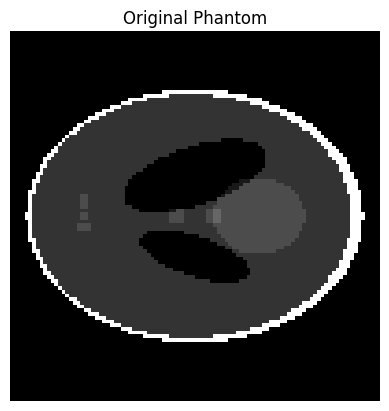

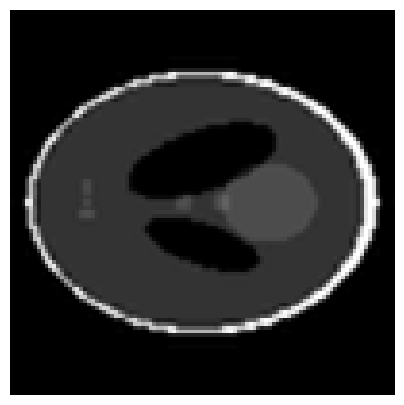

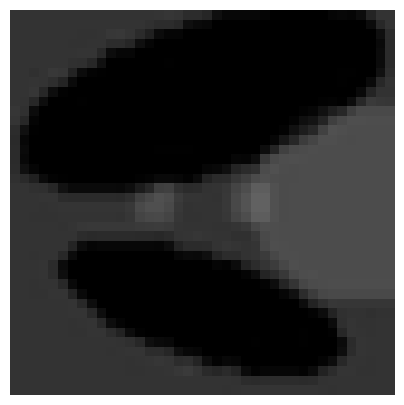

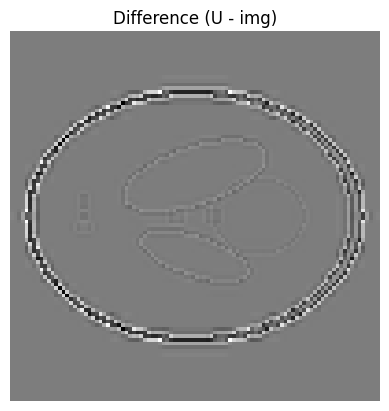

In [2]:
from src.dg_stuff import eval_dg_modal_on_img_grid, l2_project_image_to_dg
from src.siac import apply_siac_modal_dg
from src.helpers import save_and_plot_image_with_zoom

#### Testing on the noiseless phantom ####

xmin, ymin = space.min_pt
xmax, ymax = space.max_pt

# Admissible degrees: 0, 1, 3, 4, 9    (can be resolved internally by l2_project function)
deg = 3

dg = l2_project_image_to_dg(recon=phantom, xlim=(xmin,xmax), ylim=(ymin,ymax), deg=deg)

deg = dg["mesh"]["p"]
print(f"degree used: p = {deg}")

U_noiseless = eval_dg_modal_on_img_grid(dg=dg)

plt.imshow(phantom_np, cmap="gray")
plt.title("Original Phantom")
plt.axis("off")
plt.show

save_and_plot_image_with_zoom(
    U_noiseless,
    save_path=f"../figures/l2_proj_noiseless_deg{deg}.pdf",
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
    raw=True,
    show=True,
    save=True,
    dpi=600
)

plt.figure()
plt.imshow(U_noiseless - phantom_np, cmap="gray")
plt.title("Difference (U - img)")
plt.axis("off")
plt.show()

In [3]:
filter_used = "Ram-Lak"
fbp_ramp = reconstruct_fbp(sino_noisy, A, filter_name=filter_used)

degree used: p = 9


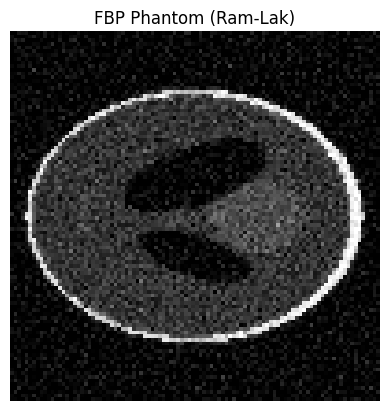

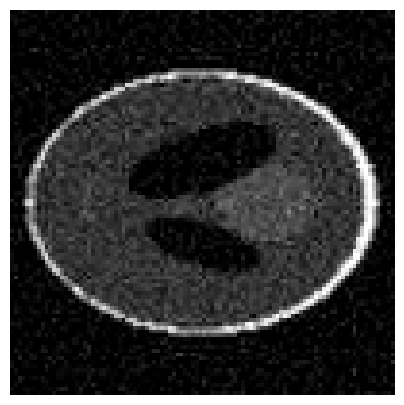

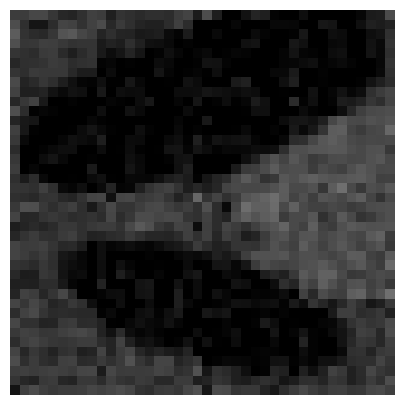

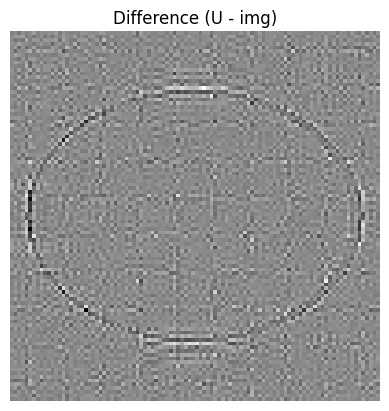

In [4]:
#### Testing on the noisy backprojected phantom ####

xmin, ymin = space.min_pt
xmax, ymax = space.max_pt

# Admissible degrees: 0, 1, 3, 4, 9    (can be resolved internally by l2_project function)
deg = 9

dg = l2_project_image_to_dg(recon=fbp_ramp, xlim=(xmin,xmax), ylim=(ymin,ymax), deg=deg)

deg = dg["mesh"]["p"]
print(f"degree used: p = {deg}")

U = eval_dg_modal_on_img_grid(dg=dg)

plt.imshow(fbp_ramp.asarray(), cmap="gray", vmin=0, vmax=1)
plt.title(f"FBP Phantom ({filter_used})")
plt.axis("off")
plt.show

save_and_plot_image_with_zoom(
    U,
    save_path=f"../figures/l2_proj_fbp_ramp_deg{deg}.pdf",
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
    raw=True,
    show=True,
    save=True,
    dpi=600
)

plt.figure()
plt.imshow(U - fbp_ramp.asarray(), cmap="gray")
plt.title("Difference (U - img)")
plt.axis("off")
plt.show()

degree used: p = 1
halfwidth = 1.5
pad = 2
shifts = [-2 -1  0  1  2]
required pad = 2

required: pad >= max(|shifts|)
coeffs shape: (54, 54, 2, 2)
orig_Kx, orig_Ky: 50 50
pad: 2
expected: coeffs.shape == (orig_Ky + 2*pad, orig_Kx + 2*pad, order, order)
x_bounds: (2, 52)
original x-range: (2, 52)
required: pad >= x_bounds[0], pad + orig_Kx <= x_bounds[1]
y_bounds: (2, 52)
original y-range: (2, 52)
required: pad >= y_bounds[0], pad + orig_Ky <= y_bounds[1]
Ustar shape before clipping: (54, 54, 2, 2)
Ustar shape after clipping: (50, 50, 2, 2)
expected: (50, 50, 2, 2)


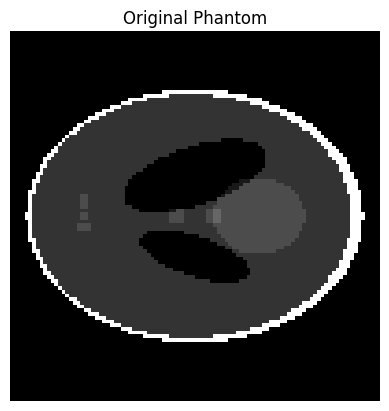

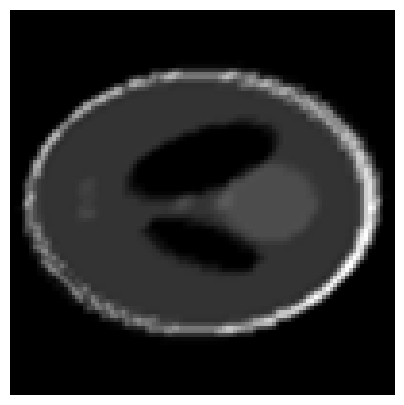

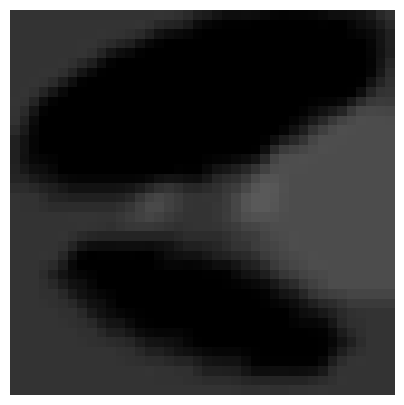

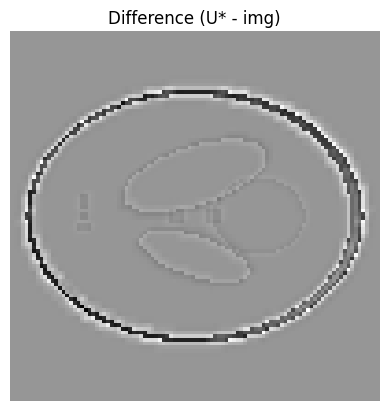

max U* = 1.0154226144913134
max img = 1.0
min U* = -0.04772592405901498
min img = -1.4901161193847656e-08


In [17]:
#### Testing on the noiseless phantom, with SIAC postprocessing ####

xmin, ymin = space.min_pt
xmax, ymax = space.max_pt

# Admissible degrees: 0, 1, 3, 4, 9    (can be resolved internally by l2_project function)
deg = 1

dg = l2_project_image_to_dg(recon=phantom, xlim=(xmin,xmax), ylim=(ymin,ymax), deg=deg)

deg = dg["mesh"]["p"]
print(f"degree used: p = {deg}")

r = 2
n = 1
# pad_boundary=True means: pad with zero elements such that the kernel can pass over the entire image
# assumption: Anything outside the original phantom should be zero
Ustar_noiseless = apply_siac_modal_dg(dg=dg, moments=r, BSorder=n, pad_boundary=True)


plt.imshow(phantom_np, cmap="gray")
plt.title("Original Phantom")
plt.axis("off")
plt.show

save_and_plot_image_with_zoom(
    Ustar_noiseless,
    save_path=f"../figures/l2_proj_fbp_ramp_SIAC_r{r}n{n}_deg{deg}.pdf",
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
    raw=True,
    show=True,
    save=True,
    dpi=600
)

plt.figure()
plt.imshow(Ustar_noiseless - phantom_np, cmap="gray")
plt.title("Difference (U* - img)")
plt.axis("off")
plt.show()

print(f"max U* = {np.max(Ustar_noiseless)}\nmax img = {np.max(phantom_np)}")
print(f"min U* = {np.min(Ustar_noiseless)}\nmin img = {np.min(phantom_np)}")


degree used: p = 1
halfwidth = 1.5
pad = 2
shifts = [-2 -1  0  1  2]
required pad = 2

required: pad >= max(|shifts|)
coeffs shape: (54, 54, 2, 2)
orig_Kx, orig_Ky: 50 50
pad: 2
expected: coeffs.shape == (orig_Ky + 2*pad, orig_Kx + 2*pad, order, order)
x_bounds: (2, 52)
original x-range: (2, 52)
required: pad >= x_bounds[0], pad + orig_Kx <= x_bounds[1]
y_bounds: (2, 52)
original y-range: (2, 52)
required: pad >= y_bounds[0], pad + orig_Ky <= y_bounds[1]
Ustar shape before clipping: (54, 54, 2, 2)
Ustar shape after clipping: (50, 50, 2, 2)
expected: (50, 50, 2, 2)


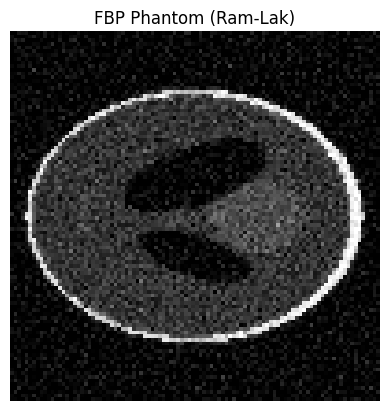

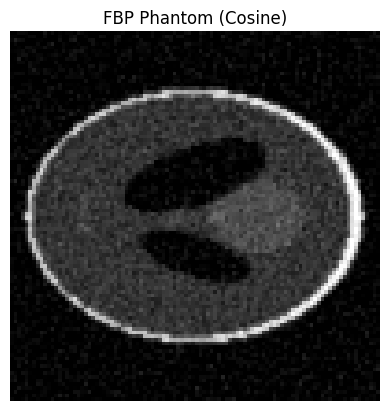

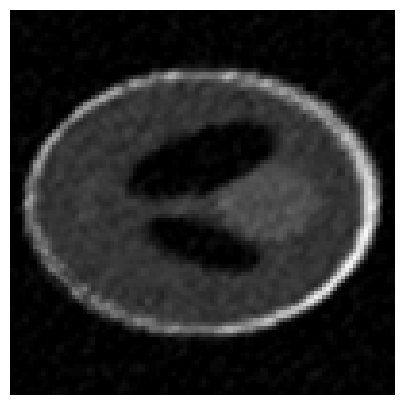

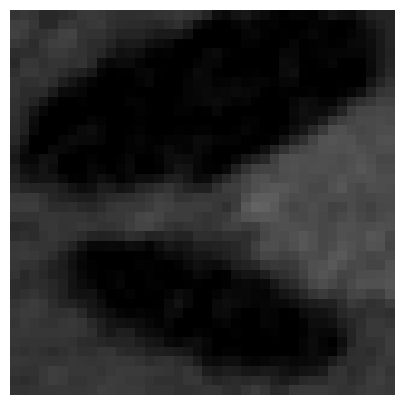

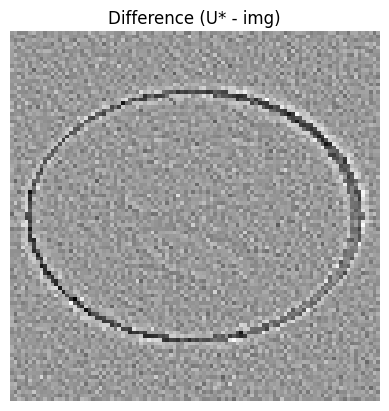

In [16]:
#### Testing on the noisy backprojected phantom, with SIAC postprocessing ####
xmin, ymin = space.min_pt
xmax, ymax = space.max_pt

# Admissible degrees: 0, 1, 3, 4, 5, 9    (can be resolved internally by l2_project function)
deg = 1

dg = l2_project_image_to_dg(recon=fbp_ramp, xlim=(xmin,xmax), ylim=(ymin,ymax), deg=deg)

deg = dg["mesh"]["p"]
print(f"degree used: p = {deg}")

r = 2
n = 1
# pad_boundary=True means: pad with zero elements such that the kernel can pass over the entire image
# assumption: Anything outside the original phantom should be zero
Ustar = apply_siac_modal_dg(dg=dg, moments=r, BSorder=n, pad_boundary=True)


plt.imshow(fbp_ramp.asarray(), cmap="gray", vmin=0, vmax=1)
plt.title(f"FBP Phantom ({filter_used})")
plt.axis("off")
plt.show()


# Compare against cosine filter FBP
fbp_cosine = reconstruct_fbp(sino_noisy, A, filter_name="cosine")
plt.imshow(fbp_cosine.asarray(), cmap="gray", vmin=0, vmax=1)
plt.title(f"FBP Phantom (Cosine)")
plt.axis("off")
plt.show()

save_and_plot_image_with_zoom(
    Ustar,
    save_path=f"../figures/l2_proj_fbp_ramp_SIAC_r{r}n{n}_deg{deg}.pdf",
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
    raw=True,
    show=True,
    save=True,
    dpi=600
)


plt.figure()
plt.imshow(Ustar - fbp_ramp.asarray(), cmap="gray")
plt.title("Difference (U* - img)")
plt.axis("off")
plt.show()

In [13]:
#### Evaluate metrics for given reconstructions ####
from src.metrics import build_metrics_table

cases = {
    "FBP-ramp": {
        "image": fbp_ramp.asarray(),
    },
    "FBP-cosine": {
        "image": fbp_cosine.asarray(),
        "reference": fbp_ramp.asarray(),
    },
    "L2(FBP-ramp)": {
        "image": U,
        "reference": fbp_ramp.asarray(),
    },
    "SIAC(L2(FBP-ramp))": {
        "image": Ustar,
        "reference": fbp_ramp.asarray(),
    },

}

dx, dy = space.cell_sides

df = build_metrics_table(
    cases,
    truth=phantom_np,
    dx=dx,
    dy=dy,
    hf_frac=0.6,
)

df

,name,truth_rel_l2_err,truth_ssim,truth_gw_ssim,truth_gradient_error,ref_rel_l2_err,ref_removed_energy_rel,ref_hf_removed_energy_rel_hf
0,FBP-ramp,0.366098,0.389971,0.889483,0.604699,NaN,NaN,NaN
1,FBP-cosine,0.311833,0.519869,0.883733,0.505533,0.236161,0.055772,0.441653
2,L2(FBP-ramp),0.369327,0.448765,0.847383,0.593489,0.288291,0.083111,0.761039
3,SIAC(L2(FBP-ramp)),0.464902,0.617633,0.675972,0.766944,0.447545,0.200296,0.996903


**Notes**

Observe that the relative high frequency (hf) content removed is $\sim 99\%$, which is good, and in the zoomed version this is well observed.

However, the image is still very blurry. 

SSIM (structural similarity index measure) is higher for the $\mathrm{SIAC}(L^2(\mathrm{FBP}_{\mathrm{ramp}}))$ than the cosine filter, but the relative $L^2$ and gradient errors are larger. Additionally, the gradient weighted SSIM is also worse for the SIAC result.

Gradient-weighted SSIM: 0.6547133145106929


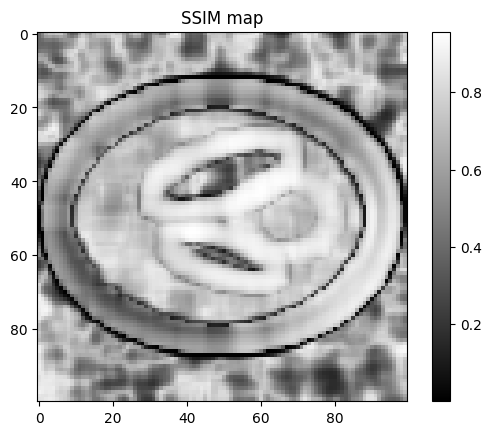

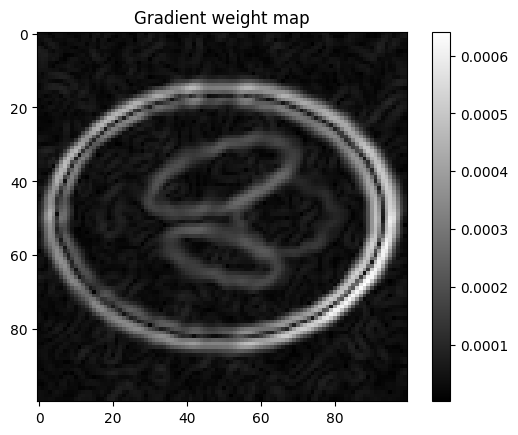

In [12]:
from src.metrics import gradient_weighted_ssim
gw, ssim_map, wmap = gradient_weighted_ssim(
    phantom_np, Ustar, alpha=0.75, sigma=1.0,
    return_maps=True
    )
print("Gradient-weighted SSIM:", gw)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(ssim_map, cmap="gray")
plt.title("SSIM map")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(wmap, cmap="gray")
plt.title("Gradient weight map")
plt.colorbar()
plt.show()